# 04 · Multiple Comparisons & Sequential Testing

* How FWER inflates in A/A/A/A tests, and how power drops in A/B/C/D tests
* Comparing corrections (Bonferroni, Šidák, Holm–Šidák, Simes–Hochberg, Hommel): alpha level vs power
* Monte Carlo sample-size calculation for multi-group tests with a correction
* The peeking problem, SPRT for conversions, and mSPRT

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm import tqdm

# Multiple testing
##  1. A/A simulations

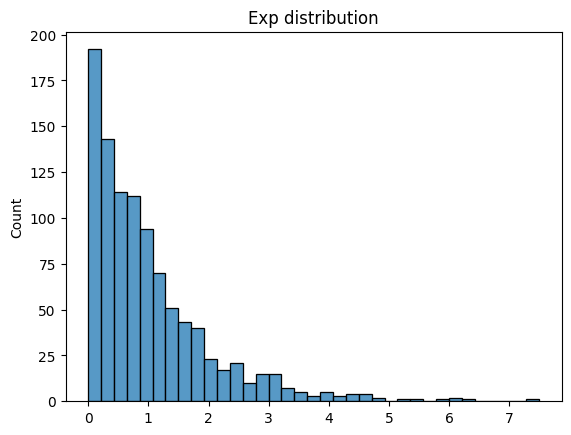

In [ ]:
sns.histplot(np.random.exponential(scale=1, size=1000))
plt.title('Exp distribution')
plt.show()

In [ ]:
# Standard A/A test
p_vals_lst = []

for i in range(10000):
    group_A1 = np.random.exponential(scale=1, size=1000)
    group_A2 = np.random.exponential(scale=1, size=1000)

    p_val = stats.ttest_ind(group_A1, group_A2).pvalue

    # Reject if any hypothesis has p < 0.05
    p_vals_lst.append(p_val)

p_vals_lst = np.array(p_vals_lst)
print("Alpha level for 1 comparison: ", np.mean(p_vals_lst < 0.05))

Alpha level for 1 comparison:  0.047


In [ ]:
# Generate an A/A/A/A test from an exponential distribution;
# but compare only with the 1st group, so the results are comparable with the A/B/C/D test
decisions = []

for i in range(1000):
    group_A1 = np.random.exponential(scale=1, size=2000)
    group_A2 = np.random.exponential(scale=1, size=2000)
    group_A3 = np.random.exponential(scale=1, size=2000)
    group_A4 = np.random.exponential(scale=1, size=1000)

    p_val1 = stats.ttest_ind(group_A1, group_A2).pvalue
    p_val2 = stats.ttest_ind(group_A1, group_A3).pvalue
    p_val3 = stats.ttest_ind(group_A1, group_A4).pvalue

    # Reject if any hypothesis has p < 0.05
    d = int(p_val1 < 0.05 or p_val2 < 0.05 or p_val3 < 0.05)
    decisions.append(d)


print("Alpha level for 3 comparisons: ", np.mean(decisions))

Alpha level for 3 comparisons:  0.135


## 2. A/B simulations

In [ ]:
from statsmodels.stats.power import tt_ind_solve_power

control_mean, treat_mean = 1, 1.1
control_std = 1     # standard deviation in the control group

cohen_d = (treat_mean - control_mean) / control_std

n = tt_ind_solve_power(
    effect_size=cohen_d,
    alpha=0.05,
    power=0.8,
    ratio=1,    # n2/n1 - ratio of group sizes (ni - sample size of group i); needed for unbalanced groups
    alternative="two-sided"
)

sample_size = round(n)
print(f"Sample size (per group): {sample_size}")

Sample size (per group): 1571


In [ ]:
# Standard A/B test simulation
decisions = []

for i in range(10000):
    group_A = np.random.normal(loc=1, scale=1.0, size=sample_size)
    group_B = np.random.normal(loc=1.1, scale=1.0, size=sample_size)

    p_val = stats.ttest_ind(group_A, group_B).pvalue

    # Reject if any hypothesis has p < 0.05
    if p_val < 0.05:
        dcn = 1
    else:
        dcn = 0
    decisions.append(dcn)


print("Power for A/B: ", np.mean(decisions))

Power for A/B:  0.7967


In [ ]:
# A/B/C/D test
power_lst = []
second_type_errors_lst = []


for i in range(10000):
    group_A = np.random.normal(loc=1, scale=1.0, size=sample_size)
    group_B = np.random.normal(loc=1.1, scale=1.0, size=sample_size)
    group_C = np.random.normal(loc=1.1, scale=1.0, size=sample_size)
    group_D = np.random.normal(loc=1.1, scale=1.0, size=sample_size)

    p_val1 = stats.ttest_ind(group_A, group_B).pvalue
    p_val2 = stats.ttest_ind(group_A, group_C).pvalue
    p_val3 = stats.ttest_ind(group_A, group_D).pvalue

    # Reject if any hypothesis has p < 0.05
    sim_power = int((p_val1 < 0.05) & (p_val2 < 0.05) & (p_val3 < 0.05))
    power_lst.append(sim_power)

    # add all 3 decisions at once
    second_type_errors_lst += [p_val1 < 0.05, p_val2 < 0.05, p_val3 < 0.05]

print("Power for A/B/C/D (all hypotheses): ", np.mean(power_lst))
print("Type II error for A/B/C/D (per hypothesis): ", 1-np.mean(second_type_errors_lst))

Power for A/B/C/D (all hypotheses):  0.6128
Type II error for A/B/C/D (per hypothesis):  0.19863333333333333


## 3. FWER

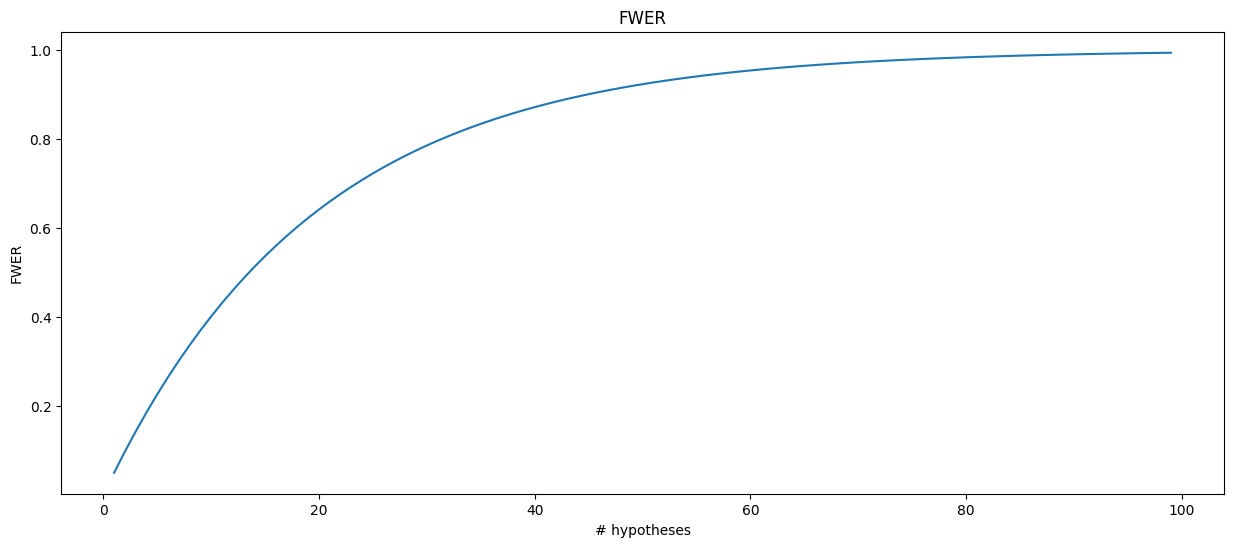

In [ ]:
numb_of_tests = list(range(1, 100))

plt.figure(figsize=(15, 6))
FWER = [1 - (1 - 0.05) ** m for m in numb_of_tests]

plt.plot(numb_of_tests, FWER)
plt.title('FWER')
plt.xlabel('# hypotheses')
plt.ylabel('FWER')
plt.show()

## 4. Corrections
Library method: https://www.statsmodels.org/dev/generated/statsmodels.stats.multitest.multipletests.html

Source code of the corrections in multipletests: https://github.com/statsmodels/statsmodels/blob/410e351dca347195779a2993c7c590e553ba2b1f/statsmodels/stats/multitest.py#L63

Code from an article comparing the methods: https://github.com/aspnmrv/multiple_comparisons/blob/main/habr_multiple_comparisons.ipynb



In [ ]:
from statsmodels.stats.multitest import multipletests

In [ ]:
# Generate an A/A/A/A test from an exponential distribution;
# but compare only with the 1st group, so the results are comparable with the A/B/C/D test
p_vals_AAAA = []

for i in range(1000):
    group_A1 = np.random.exponential(scale=1, size=2000)
    group_A2 = np.random.exponential(scale=1, size=2000)
    group_A3 = np.random.exponential(scale=1, size=2000)
    group_A4 = np.random.exponential(scale=1, size=1000)

    p_val1 = stats.ttest_ind(group_A1, group_A2).pvalue
    p_val2 = stats.ttest_ind(group_A1, group_A3).pvalue
    p_val3 = stats.ttest_ind(group_A1, group_A4).pvalue

    p_vals_AAAA.append([p_val1, p_val2, p_val3])

# A/B/C/D
p_vals_ABCD = []
for i in range(1000):
    group_A = np.random.normal(loc=1, scale=1.0, size=sample_size)
    group_B = np.random.normal(loc=1.1, scale=1.0, size=sample_size)
    group_C = np.random.normal(loc=1.1, scale=1.0, size=sample_size)
    group_D = np.random.normal(loc=1.1, scale=1.0, size=sample_size)

    p_val1 = stats.ttest_ind(group_A, group_B).pvalue
    p_val2 = stats.ttest_ind(group_A, group_C).pvalue
    p_val3 = stats.ttest_ind(group_A, group_D).pvalue

    p_vals_ABCD.append([p_val1, p_val2, p_val3])


p_vals_AAAA, p_vals_ABCD = np.array(p_vals_AAAA), np.array(p_vals_ABCD)
p_vals_AAAA.shape, p_vals_ABCD.shape

((1000, 3), (1000, 3))

In [ ]:
p_vals_AAAA

array([[0.86807058, 0.12642112, 0.82087539],
       [0.86002585, 0.43653748, 0.72672128],
       [0.20867294, 0.49114364, 0.81948222],
       ...,
       [0.62587656, 0.35295707, 0.61222723],
       [0.6600918 , 0.30641454, 0.90967896],
       [0.70305722, 0.58918824, 0.59913861]])

Methods:
1. bonferroni : one-step correction
2. sidak : one-step correction
3. holm-sidak : step down method using Sidak adjustments
4. holm : step-down method using Bonferroni adjustments
5. simes-hochberg : step-up method (independent)
6. hommel : closed method based on Simes tests (non-negative)
7. fdr_bh : Benjamini/Hochberg (non-negative)
8. fdr_by : Benjamini/Yekutieli (negative)
9. fdr_tsbh : two stage fdr correction (non-negative)
10. fdr_tsbky : two stage fdr correction (non-negative)

In [ ]:
# 1. Bonferroni
alpha_lvl = 0.05
m = 3

alpha = (p_vals_AAAA < alpha_lvl / m).sum(axis=1).astype(bool).mean()
power = ((p_vals_ABCD < alpha_lvl / m).sum(axis=1) == m).mean()

print(f"[Bonferroni correction], alpha level: {alpha}, power: {power}")

[Bonferroni correction], alpha level: 0.037, power: 0.393


In [ ]:
# check how FWER behaves when a correction is applied

def check_correction(method):
    lst_AAAA = []
    for i in range(len(p_vals_AAAA)):
        a = multipletests(p_vals_AAAA[i], alpha = 0.05, method = method)[0]
        lst_AAAA.append(sum(a) > 0)

    lst_ABCD = []
    for i in range(len(p_vals_ABCD)):
        a = multipletests(p_vals_ABCD[i], alpha = 0.05, method = method)[0]
        lst_ABCD.append(sum(a) == 3)

    print(f"[{method} correction], alpha level: {np.mean(lst_AAAA)}, power: {np.mean(lst_ABCD)}")

In [ ]:
check_correction('bonferroni')

[bonferroni correction], alpha level: 0.037, power: 0.393


In [ ]:
check_correction('sidak')

[sidak correction], alpha level: 0.038, power: 0.396


In [ ]:
check_correction('holm-sidak')

[holm-sidak correction], alpha level: 0.038, power: 0.564


In [ ]:
check_correction('simes-hochberg')

[simes-hochberg correction], alpha level: 0.038, power: 0.588


In [ ]:
check_correction('hommel')

[hommel correction], alpha level: 0.038, power: 0.588


## 5. Sample size function

In [ ]:
from tqdm import tqdm
from statsmodels.stats.power import tt_ind_solve_power
from scipy.stats import ttest_ind


In [ ]:

def multi_test_sample_size(
        data,                       # metric for which the sample size is calculated
        effects_lst = [0, 0.1],     # MDE (as a relative effect)
        n_groups = 2,               # number of compared groups (including control)
        alpha = 0.05,               # significance level
        power_level=0.8,            # power threshold at which to stop
        start_sample_size=100,      # start sampele size
        step_size=100,              # sample size added at each step
        n_sim=10**3,                # number of iterations at each step
        method = 'holm-sidak',      # library correction method
        _test = ttest_ind

):
    '''
    return sample size
    '''
    sample_size = start_sample_size

    sample_size_lst = []
    power_lst = []
    power_each_test = []

    while True:

        p_vals = []
        for i in range(n_sim):
            groups = []

            # Create the groups
            for i in range(n_groups):
                elem = np.random.choice(data, size = sample_size) * (1 + effects_lst[i])
                groups.append(elem)

            # Compare each group with the first (control) group
            tmp = []
            for i in range(1, n_groups):
                _, p_val = _test(groups[0], groups[i])
                tmp.append(p_val)
            p_vals.append(tmp)

        p_vals = np.array(p_vals)
        # res = (p_vals < alpha).sum(axis=1) == (n_groups-1)

        # FWER correction
        lst_h = []
        for i in range(len(p_vals)):
            lst_h.append(multipletests(p_vals[i], alpha = 0.05, method = method)[0])


        each_power = np.array(lst_h).sum(axis=0) / n_sim
        # print(each_power)
        # return
        FWER_power = np.mean(np.array(lst_h).sum(axis=1) == (n_groups-1))    # == FWER II type

        # add elements
        power_each_test.append(each_power)
        power_lst.append(FWER_power)
        sample_size_lst.append(sample_size)

        # stop rules
        if FWER_power > power_level + 0.01:
            print(f"Final result => Sample size: {sample_size}, FWER power: {FWER_power}, power (each test): {each_power}")
            break
        else:
            sample_size += step_size

        print(f"Sample size: {sample_size}, FWER power: {FWER_power}, power (each test): {each_power}")
    return sample_size_lst, np.array(power_lst), np.array(power_each_test)

In [ ]:
def generate_data(n_users: int = 10 ** 5, n_metrics: int = 100) -> pd.DataFrame:
    user_ids = np.arange(n_users)
    data = pd.DataFrame(user_ids, columns=["user_id"])
    for metric_number in range(n_metrics):
        data = pd.concat(
            [
                data,
                pd.DataFrame(
                    np.random.normal(100, 10, size=n_users)
                    * np.random.choice([0, 1], size=n_users, p=[0.9, 0.1]),
                    columns=[f"metric_{metric_number}"],
                    index=data.index,
                ),
            ],
            axis=1,
        )
    data = data.set_index("user_id")
    return data


In [ ]:
data = generate_data(10**4, 3)

sample_size_lst, power_lst, power_each_test = multi_test_sample_size(
    data['metric_0'],
    effects_lst= [0, 0.5, 0.5, 0.9, 0.5],
    n_groups=5,
    step_size=500
)

Sample size: 600, FWER power: 0.01, power (each test): [0.047 0.046 0.107 0.054]
Sample size: 1100, FWER power: 0.315, power (each test): [0.515 0.513 0.871 0.533]
Sample size: 1600, FWER power: 0.705, power (each test): [0.846 0.835 0.992 0.819]
Final result => Sample size: 1600, FWER power: 0.905, power (each test): [0.953 0.958 1.    0.964]


In [ ]:
control_mean, treat_mean = data['metric_0'].mean(), data['metric_0'].mean() * (1 + 0.5)
control_std = data['metric_0'].std()

cohen_d = (treat_mean - control_mean) / control_std

n = tt_ind_solve_power(
    effect_size=cohen_d,
    nobs1 = None,
    alpha=0.05,
    power=0.853,
    ratio=1,
    alternative="two-sided"
)

print(f"Without correction we would need: {round(n)} users per group")
print(f"With correction: {sample_size_lst[-1]} per group")

Without correction we would need: 651 users per group
With correction: 1600 per group


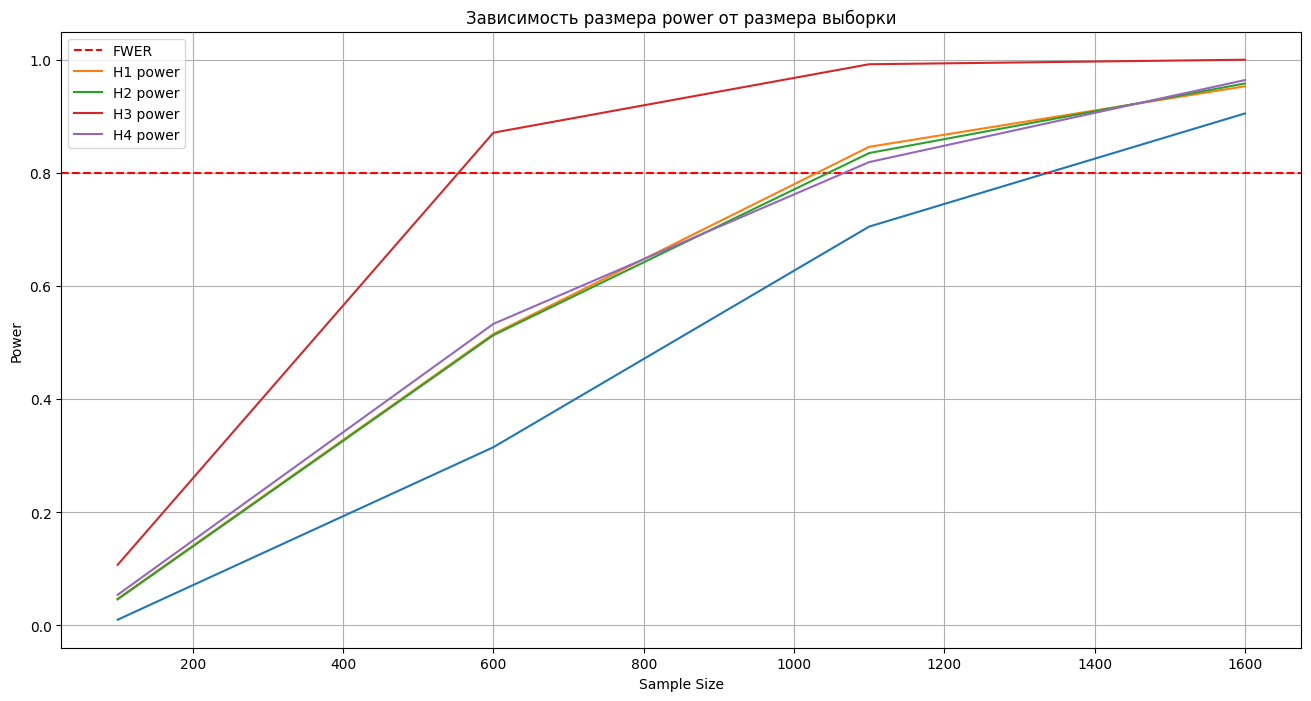

In [ ]:
plt.figure(figsize = (16, 8))
sns.lineplot(x= sample_size_lst, y = power_lst)
plt.axhline(y = 0.8, linestyle  = '--', color = 'red', label='FWER')

sns.lineplot(x= sample_size_lst, y = power_each_test[:, 0], label='H1 power')
sns.lineplot(x= sample_size_lst, y = power_each_test[:, 1], label='H2 power')
sns.lineplot(x= sample_size_lst, y = power_each_test[:, 2], label='H3 power')
sns.lineplot(x= sample_size_lst, y = power_each_test[:, 3], label='H4 power')

plt.title('Power as a function of sample size')
plt.xlabel("Sample Size")
plt.ylabel("Power")
plt.grid(True)
plt.legend()
plt.show()

# Sequential testing



## The peeking problem

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as st
import seaborn as sns
import matplotlib.pyplot as plt


n_users = 10 ** 3
data_a = generate_data(n_users, 1)
data_b = generate_data(n_users, 1)
p_values = []
for time in range(100, n_users):
    time_slice_a = data_a.iloc[:time]["metric_0"]
    time_slice_b = data_b.iloc[:time]["metric_0"]
    p_values.append(st.ttest_ind(time_slice_a, time_slice_b)[1])


plt.figure(figsize=(15, 7))
sns.lineplot(x=range(100, n_users), y=p_values)

plt.yticks(np.arange(0, max(p_values), 0.05))
plt.xticks(np.arange(0, n_users, 100))
plt.ylim(-0.1, max(p_values))
plt.gca().invert_yaxis()
plt.axhline(0.05, color="green", linestyle="--", linewidth=2)


plt.xlabel("Users_n")
plt.ylabel("p-value")
plt.title("p-value over time")
plt.show()


NameError: name 'generate_data' is not defined

## SPRT test

Library code: https://github.com/copperheadCrotch/Sequential-Probability-Ratio-Test/blob/master/sprt/sprt.py

In [ ]:
# function that tests the hypothesis of equal proportions with SPRT
def SPRT_conversion(
    group_A,        # array of conversion values in group A
    group_B,        #
    alpha = 0.05,
    beta = 0.2,
    mde = 0.1       # absolute MDE
):
    ''' SPRT for proportions; stops the first time a boundary is crossed'''
    A = np.log(beta/(1 - alpha))
    B = np.log((1 - beta)/alpha)

    S_lst = []

    for i in range(100, int(np.min([len(group_A), len(group_B)]))):
        s1 = np.mean(group_A[:i])
        s2 = np.mean(group_B[:i])

        p = (s1 + s2)/2
        D = p * (1 - p)
        S = (i + 1) * (s2 - s1 - mde/2) * mde / D / 2
        S_lst.append(S)

        if S < A or S > B:
            continue
            # break

    return np.array(S_lst), A, B

In [ ]:
data_A = np.random.binomial(n=1, p=0.5, size=10**4)
data_B = np.random.binomial(n=1, p=0.501, size=10**4)

S_lst, A, B = SPRT_conversion(data_A, data_B, mde=0.01)

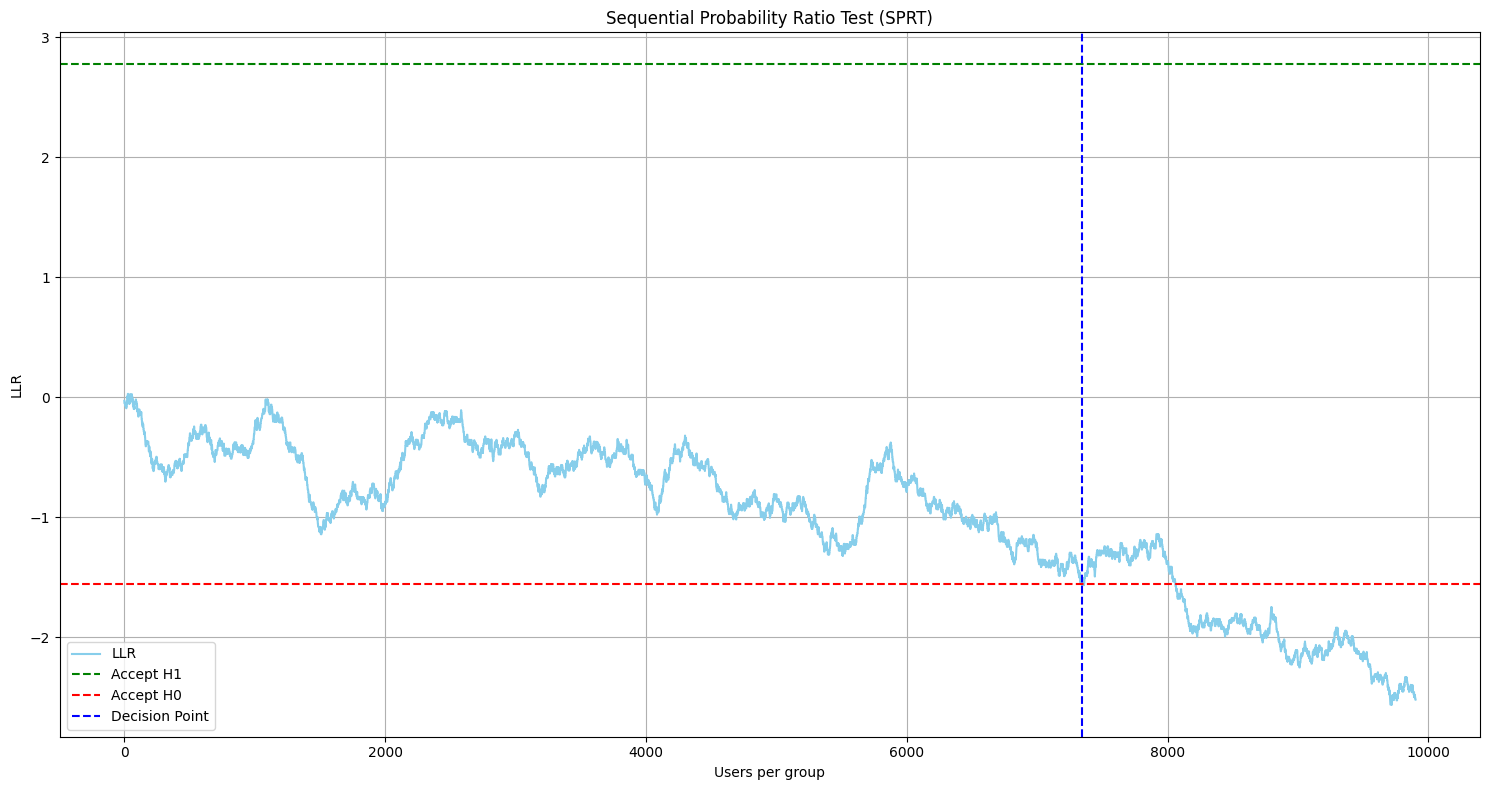

In [ ]:
plt.figure(figsize=(15, 8))

# Plot LLR
plt.plot(range(1, len(S_lst)+1), S_lst, label="LLR", color='skyblue')   #

# Horizontal lines for acceptance/rejection thresholds
plt.axhline(B, color='green', linestyle='--', label="Accept H1")
plt.axhline(A, color='red', linestyle='--', label="Accept H0")

# Vertical line for decision point
plt.axvline(np.argmax((S_lst > B) | (S_lst < A)), color='blue', linestyle='--', label="Decision Point")

# Add labels and title
plt.title("Sequential Probability Ratio Test (SPRT)")
plt.xlabel("Users per group")
plt.ylabel("LLR")

# Show legend
plt.legend()

# Show grid and plot
plt.grid(True)
plt.tight_layout()
plt.show()


## mSPRT test

Library code: https://github.com/ovidijusku/msprt/blob/main/src/msprt/msprt_.py

In [ ]:
!pip install msprt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 70.0 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.7.1
    Uninstalling matplotlib-3.7.1:
      Successfully uninstalled matplotlib-3.7.1


In [ ]:
from msprt import msprt
n = 700
x = np.random.exponential(0, n)
y = np.random.exponential(0.2, n)


In [ ]:
result = msprt(x=x, y=y, sigma=1.0)
print(result)


Distribution: 'normal',
number of observations: 700,
rejection after: 482,
decision: 'Accept H1',
text: 'Decision made after 482 observations were collected',
alpha: 0.05


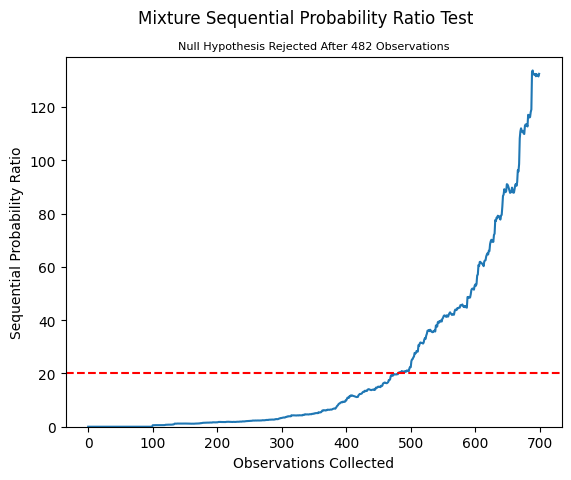

In [ ]:
result.plot()